# **Auriga simulation analysis tutorial**

This python notebook contains a series of examples for loading, manipulating, and analysing the following data products:

- snapshots (particle data)
- group/subhalo catalogues
- merger trees
- accreted star information

This includes:

- Read snapshot data for a single particle type;
- Read the subhalo catalogues and fields;
- Center on the main galaxy and select particles;
- Converting stellar particle formation times to lookback times;
- Read and navigate the merger tree data to retrieve evolutionary histories of subhalos;
- Use the supplementary accreted star particle data to select particles from specific progenitors;
- Combine this additional information with the snapshot and merger tree data.

# **Snapshots**

Each Auriga simulation stores a number of snapshots containing the raw data of each particle and cell. Each snapshot (denoted by number X) is split across Y files within a snapdir_X directory. ***Need to load all files!!!***



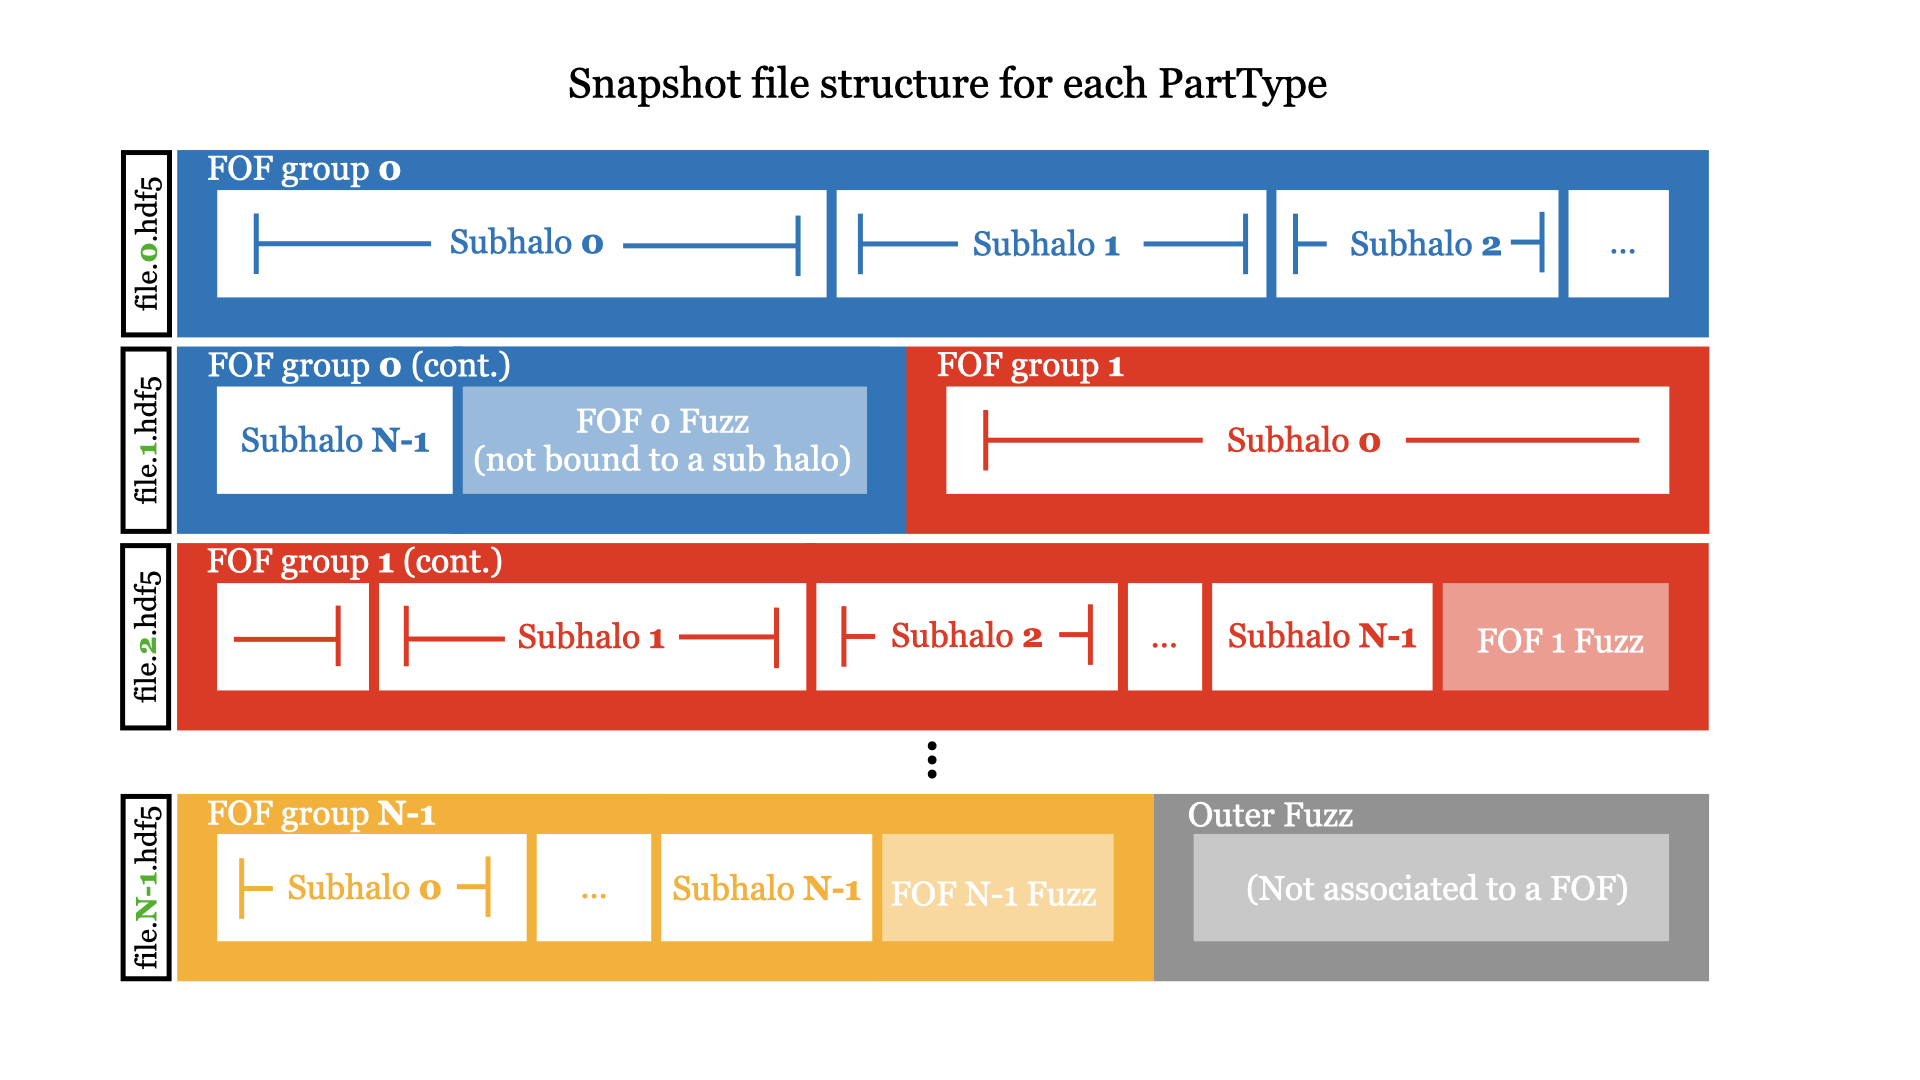

The particle/cell data in any given snapshot is organized according to their group/subgroup membership, as per the FoF or Subfind algorithms. For each particle type, the sort order is: GroupNumber, SubgroupNumber, BindingEnergy, where particles belonging to the group but not to any of its subgroups ("fuzz") are included after the last subgroup. The following figure provides a schematic view of the particle organization within a snapshot, for one particle type. Note that the truncation of a snapshot in chunks is arbitrary, thus halos may happen to be stored across multiple, subsequent chunks. Similarly, the different particle types of a halo can be stored in different sets of chunks.


HDF5 snapshots may contain several particle type groups:

*   gas cells: PartType0
*   high-resolution dark matter particles: PartType1
*   low-resolution dark matter particles: PartType2 & PartType3
*   star particles & wind particles: PartType4
*   black holes: PartType5
*   tracer particles: PartType6

For the star particles, it is important to know that each particle represents a Simple Stellar Popoulation (SSP), so each particle is itself a population of stars with a fixed age & chemical composition inherited from the gas cell in which it was born.

A detailed description of snapshot headers and particle data attributes are listed here: https://wwwmpa.mpa-garching.mpg.de/auriga/dataspecs.html

(Note: the raw data is in comoving coordinates. The analysis package we will use automatically converts to physical)

---

To analyse the data, we will be using a publicly available python package especially designed to work with Auriga, but should also be easily adaptable to other simulation outputs if formatted similarly. It is stored in the bitbucket repository https://bitbucket.org/grandrt/auriga_public/src/master/



Once you have cloned and installed the package on your local machine, define the directory where the data to be analysed is located. For these examples, we will work with halo 6 of the Original level 4 MHD runs. To be consistent with the format of the globus file structure, we will define the following:

In [ ]:
# AHR: put everything involving path-finding up here
halo = 'halo_6'
directory = f'/Users/ahriley/data/auriga/level4/{halo}/'
tree_directory = f'/Users/ahriley/data/auriga/level4/mergertrees/{halo}/'
list_directory = '/Users/ahriley/data/auriga/level4/accretedstardata/'

snap_num = 127

In [ ]:
import glob
path = glob.glob(directory+'/*')
print('path',path)

Once this is all working and set up, import the auriga_public package

In [ ]:
import auriga_public as ap
import numpy as np

We will be dealing with star particles mainly, so we will load the PartType4 star & wind particles from the snapshot specified by the snapshot number and directory, loading only the list of attributes passed to the loadlist keyword.

In [ ]:
"""
class load_snapshot()

    Parameters:
        snap_num:     int
                      number of the snapshot to be analysed
        partType:     int
                      the particle type to be loaded from the snapshot (0: gas; 1: DM; 4: stars & winds; 5: BHs)
        loadlist:     list, optional
                      A list of data attributes to load, for examples, ['Masses', 'Coordinates', 'Velocities']. If False, everything will
                      be loaded. Default is False.
        snappath:     str
                      directory path to the snapshot data. Default is '.'
        applytransformationfacs:      boolean
                                      Default is True. If True, cosmolofical transformation factors will be applied to data fields.


    Returns:
        Snapshot class object containing particle data dictionaries, header information...

"""

In [ ]:
"""
load_snapshot_header()
      Function:     To read the header information of the snapshot file(s), such as numer of particles/cells, and cosmological parameters.

      Parameters:
          fileid:   int
                    the snapshot "chunk" number to be read. Snapshots are split into several chunks, which are read sequentially in this method.


load_snapshot_data()
      Function:     To read the particle/cell data foudn in the snapshot file(s).

      Parameters:
          ptype:   int
                   particle type to be read (given by class input)

          loadlist:     list

set_transformation_factors()
      Function: Set the cosmological transformation factors for data attributes.

apply_transformation_factors()
      Function: Apply the transformation of data attributes using the factors from set_transformation_factors()

"""

For the purposes of this tutorial, we will mainly be working with star particles (PartType4) in the final redshift zero snapshot, which in this case is snapshot 127. We also choose to load several relevant data attributes of star particles, including their coordinates, velocities, formation times, intial masses, current masses, particle IDs, and gravitational potentials. We then create a snapshot object containing this data:

In [ ]:
partType = 4
attrstoload = ['Coordinates', 'Velocities', 'GFM_StellarFormationTime', 'GFM_InitialMass', 'Masses', 'ParticleIDs', 'Potential']
outputdir = directory
snapdir = 'snapdir_%03d/'%snap_num
snapobj = ap.snapshot.load_snapshot(snap_num, partType, loadlist=attrstoload, snappath=outputdir, verbose=False)

These are the raw data in box coordinates (i.e. in a comoving box of side length 100 cMpc). The first thing we'd want to do is centre the coordinates on the halo of interest, so we need to load the subhalo catalogue to retrieve the coordinates of the main halo.



In [ ]:
"""
class subfind()
    Parameters:
        snap_num:     int
                      number of the snapshot to be analysed
        directory:    str
                      directory path to the snapshot data. Default is '.'
        loadlist:     list, optional
                      A list of data attributes to load, for examples, ['SubhaloMass', 'SubhaloPos', 'GroupVel']. If False, everything will
                      be loaded. Default is False.

    Returns:
        Subhalo/group catalogue class object containing data dictionaries, header information...

"""

In [ ]:
subobj = ap.subhalos.subfind(snap_num, directory=outputdir, loadlist=['SubhaloPos', 'Group_R_Crit200'])

Using the methods in util.py, we can do a bunch of things to the data to help with analysis.

In [ ]:
"""
def GetLookbackTimeFromScaleFactor_Flat()
      Parameters:
          a:            array_like
                        cosmological scale factor of PartType4 particles or the scale factor of a given snapshot [spans from 0 to 1]
          hubbleparam:  float
                        value of the Hubble parameter used in the simulation (value found in snapshot/group data header). Default: None
          OmegaMatter:  float
                        value of the matter density used in the simulation (value found in snapshot/group data header). Default: None
          OmegaLambda:  float
                        value of the cosmological consant used in the simulation (value found in snapshot/group data header). Default: None
          HubbleConst:  float
                        value of Hubble's constant factor. Default: 100

      Returns:          array_like
                        an array of lookback times in units of Gyr

def CentreOnHalo()
      Parameters:
          snapobj:      snapshot object
          center:       array_like
                        coordinates on which to centre the particle/cell data

      Returns:          snapshot object

def remove_bulk_velocity()
      Parameters:
          snapobj:      snapshot object
          idx:          array_like of ints (optional)
                        indices of particles to be used to calculate the bulk velocity. Default is none
          radialcut:    float
                        if idx=False, select particles inside radialcut to calculate the bulk velocity

      Returns:          array_like
                        The 3-dimensional bulk velocity

def r()
      Parameters:
          snapobj:      snapshot object
          center:       array_like
                        coordinates on which to centre the particle/cell data. Default is False.

      Returns:          array_like
                        array of 3-dimensional radii of particles/cells

def apply_mask()
      Function:         Remove wind particles and/or make spatial cut on data attribute of a snapshot object
      Parameters:
          snapobj:      snapshot object
          stars:        boolean
                        If true, remove wind particles from snapshot data. Default is False.
          radialcut:    float
                        If not None, remove star/wind particles outside of specified radialcut value. Default is None.

      Returns:          snapshot object

"""

For example, we would first want to centre the particle data using the following method:

In [ ]:
"""Centre the particles/cells on the most massive subhalo (the main galaxy)"""
snapobj = ap.util.CentreOnHalo(snapobj, subobj.data['SubhaloPos'][0])

we also need to subtract off the bulk velocity of the galaxy so that all velocities are zero at the centre of the galaxy.

In [ ]:
"""Remove bulk velocity"""
bulk_velocity = ap.util.calculate_bulk_velocity(snapobj, idx=None, radialcut=0.1*subobj.data['Group_R_Crit200'][0])
ap.util.remove_bulk_velocity(snapobj, bulk_velocity)

Now that we've centred it on the centre of the MW, we can make a radial cut to select all particles inside the virial radius, and define the radii of each particle.

In [ ]:
snapobj = ap.util.apply_mask(snapobj, stars=True, radialcut=subobj.data['Group_R_Crit200'][0])

(Remember that the XYZ coordinates and radii are have been converted from cMpc/h to physical Mpc by the reading routines, so they are ready to be used. This is the case for the other fields too.)

The "ages" (given by the snapshot attribute 'GFM_StellarFormationTime') provided in the snapshot are actually in units of scale factor, a. To transform this to a lookback time we use the cosmological factors and take advantage of the fact that they approximate a flat Universe, which simplifies the calculation.

We get the ages by using the following method:

In [ ]:
ages = ap.util.GetLookbackTimeFromScaleFactor_Flat(snapobj.data['GFM_StellarFormationTime'], snapobj.hubbleparam, snapobj.omega0, snapobj.omegalambda)

In [ ]:
print('stellar ages=',ages)

Let's now plot the star formation history now that we have the ages in units of gigayears:

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt


In [ ]:
plt.hist(ages, bins=40, range=[0, 14], weights=snapobj.data['GFM_InitialMass']/(14/40)*1e10/1e9)
plt.xlabel('$\\rm age $')
plt.ylabel('$\\rm{sfr \, [M_{\odot}yr^{-1}]}$')
plt.show()

So far, we have centred the particles on the galaxy, but we have not aligned the disc to the coordinate system. Therefore, the z-component of the angular momentum axis (the one that is normal to the disc plane) is oriented along some random direction. To verify this, we can do the following:

In [ ]:
n, xedges, yedges = np.histogram2d(snapobj.data['Coordinates'][:,2], snapobj.data['Coordinates'][:,1], bins=(500,500), range=[[-0.05, 0.05],[-0.05, 0.05]])
xbin = 0.5 * (xedges[:-1] + xedges[1:])
ybin = 0.5 * (yedges[:-1] + yedges[1:])
xc, yc = np.meshgrid(xbin, ybin)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5), tight_layout=True)
ax1.set_aspect(1)
ax1.contourf( xc, yc, np.log10(n.T), cmap='magma')
n, xedges, yedges = np.histogram2d(snapobj.data['Coordinates'][:,2], snapobj.data['Coordinates'][:,0], bins=(500,500), range=[[-0.05, 0.05],[-0.05, 0.05]])
ax2.contourf( xc, yc, np.log10(n.T), cmap='magma')
fig.show()

The util class contains methods to calculate the unit vectors of angular momentum of stars (Ldir) and eigenvectors of the moment of interia tensor (returned by ap.util.get_principal_axis(snapobj, particle_indices, L=Ldir)) and to then rotate the relevant data attributes using the resulting rotation matrix (ap.util.rotateto(snapobj, xdir, dir2=ydir, dir3=zdir)).

In [ ]:
"""
def get_principal_axis()
      Parameters:
          snapobj:      snapshot object
          idx:          array_like of ints
                        an array of ParticleIDs to be used in the calculation of the eigenvectors of the inertia tensor
          Ldir:         array_like
                        unit vector of the spin axis of star particles
      Returns:          xdir, ydir, zdir
                        Eigenvectors of the inertia tensor: xdir eigenvector with largest eigenvalue (in direction of spin axis).

def rotateto()
      Function: apply rotation to particle/cell data fields using the rotation matrix constructed from input parameters

      Parameters:
          snapobj:      snapshot object
          dir:          list or array_like
                        unit vector used in rotation matrix
          dir2, dir3:   as above

def align_galaxy()
      Function: apply the routines in the above methods with a single call to this method to do the default rotation type
      Parameters:
          snapobj:      snapshot object
          idx:          array_like of ints
                        an array of ParticleIDs to be used in the calculation of the eigenvectors of the inertia tensor.
                        Default is None
          radialcut:    the radius inside which we select star particles to get the eigenvectors.
                        Default: 0.01 (Mpc)

"""

***We need to rotate the disc so it aligns with our frame of reference, and plot the face-on and edge-on view of the log number density of stars:***

In [ ]:
# To calculate it manually (flexibility to make different selection, i.e., radial cuts, gas instead...):
"""
istars, = np.where( (star_radius < 0.1*subobj.data['Group_R_Crit200'][0]) )
L = np.cross( snapobj.data['Coordinates'][istars,:], (snapobj.data['Velocities'][istars,:] * snapobj.data['Masses'][istars,None]) )
Ltot = L.sum( axis=0 )
Ldir = Ltot / np.sqrt( (Ltot**2).sum() )
print('Calculated stellar angular momentum unit vector: ',Ldir)
xdir, ydir, zdir = ap.util.get_principal_axis( snapobj, istars, L=Ldir )
print('Found eigenvector of inertia tensor aligned closest to angular momentum unit vector of stars.')
ap.util.rotateto(snapobj, xdir, dir2=ydir, dir3=zdir)
"""
# or do the default rotation in util.py
xdir, ydir, zdir = ap.util.align_galaxy( snapobj, idx=None, radialcut=0.1*subobj.data['Group_R_Crit200'][0] )
ap.util.rotateto(snapobj, xdir, dir2=ydir, dir3=zdir)
print('Applied rotation matrix. Proceeding to plot XYZ projections...')

n, xedges, yedges = np.histogram2d(snapobj.data['Coordinates'][:,2], snapobj.data['Coordinates'][:,1], bins=(500,500), range=[[-0.05, 0.05],[-0.05, 0.05]])
xbin = 0.5 * (xedges[:-1] + xedges[1:])
ybin = 0.5 * (yedges[:-1] + yedges[1:])
xc, yc = np.meshgrid(xbin, ybin)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5), tight_layout=True)
ax1.set_aspect(1)
ax1.contourf( xc, yc, np.log10(n.T), cmap='magma')
n, xedges, yedges = np.histogram2d(snapobj.data['Coordinates'][:,2], snapobj.data['Coordinates'][:,0], bins=(500,500), range=[[-0.05, 0.05],[-0.05, 0.05]])
ax2.contourf( xc, yc, np.log10(n.T), cmap='magma')
fig.show()

Now let's plot a rotation curve for the stars. In the simulation system of units, the gravitational constant, G, is equal to about 43.

First, let's get the radii of star particles:

In [ ]:
star_radius = ap.util.r(snapobj)
print(star_radius,subobj.data['Group_R_Crit200'][0])
from scipy import stats
Gcosmo = 43.

Then, get the rotation curve by cumulatively summing their mass in order of their radius:

In [ ]:
isort_stars = np.argsort(star_radius)
cummass = np.cumsum(snapobj.data['Masses'][isort_stars])
Vc_stars = np.sqrt( Gcosmo*cummass/star_radius[isort_stars] )
vbinstars, edges, bnum = stats.binned_statistic(star_radius[isort_stars], Vc_stars, statistic='mean', bins=100, range=[0., 0.1*subobj.data['Group_R_Crit200'][0]])
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
ax1.plot(0.5*(edges[:-1]+edges[1:])*1e3, vbinstars)
ax1.set_xlabel('$\\rm R[kpc] $')
ax1.set_ylabel('$\\rm{V_{circ}[km/s]}$')
fig.show()

Obviousely we need to add the dark matter as well. First, load the PartType1 (high resolution dark matter) from the snapshot. Then apply the same centering and masks as before, and calculate the radii of DM particles, before getting Vc_dm.


In [ ]:
snapobj_dm = ap.snapshot.load_snapshot(snap_num, 1, loadlist=['Coordinates', 'Masses'], snappath=outputdir, verbose=False)
snapobj_dm = ap.util.CentreOnHalo(snapobj_dm, subobj.data['SubhaloPos'][0])
snapobj_dm = ap.util.apply_mask(snapobj_dm, stars=False, radialcut=0.1*subobj.data['Group_R_Crit200'][0])
dm_radius = ap.util.r(snapobj_dm)
isort_dm = np.argsort(dm_radius)
cummass = np.cumsum(snapobj_dm.data['Masses'][isort_dm])
Vc_dm = np.sqrt( Gcosmo*cummass/dm_radius[isort_dm] )

then plot both curves and the total Vcirc together.

In [ ]:
vbindm, edges, bnum = stats.binned_statistic(dm_radius[isort_dm], Vc_dm, statistic='mean', bins=100, range=[0., 0.1*subobj.data['Group_R_Crit200'][0]])
Rbin = 0.5 * (edges[:-1] + edges[1:])
Vcirc = np.sqrt(vbinstars**2 + vbindm**2)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
ax1.plot(Rbin*1e3, vbinstars)
ax1.plot(Rbin*1e3, vbindm)
ax1.plot(Rbin*1e3, Vcirc)
fig.show()

# **Subhalo/group catalogues**

One catalogue exists for each snapshot.

The catalogues are contain gravitationally bound subhalos, which are grouped together into FOF groups. Both FOF groups and subhalos are ordered in rank of descending total mass, such that the most massive subhalo (satellite) of a group comes first. Thus, the FOF and subhalo with index 0 are the most massive group and subbhalo, respectively, which is *usually* the Milky Way analogue of interest (but not always; see the merger tree section below).

To see a more detailed list of subhalo attributes stored in the subhalo catalogues, see https://wwwmpa.mpa-garching.mpg.de/auriga/dataspecs.html

Let's now take a look at how to use the subhalo catalogues, and load information about the masses, positions, velocities or subhalos as well as the R200 of the MW.

In [ ]:
"""Load a subhalo catalogue"""
attrstoload = ['SubhaloMass', 'SubhaloPos', 'SubhaloVel', 'SubhaloMassType', 'Group_R_Crit200']
subobj = ap.subhalos.subfind(snap_num, directory=outputdir, loadlist=attrstoload)

Now let's plot the mass and distance of satellites inside R200.

In [ ]:
main_pos = subobj.data['SubhaloPos'][0]
print('main_pos=',main_pos)
distance = np.sqrt( np.sum( (subobj.data['SubhaloPos']-main_pos)**2, axis=1) )
masses = subobj.data['SubhaloMassType'][:,1]
smasses = subobj.data['SubhaloMassType'][:,4]
gmasses = subobj.data['SubhaloMassType'][:,0]
r200 = subobj.data['Group_R_Crit200'][0]

Remember that the subhalos are always ordered in terms of total mass, with the most massive listed first. This is actually the Milky Way itself, so we have to ignore the first entry to focus only on the satellites. It will also always have a distance of 0 (since we subtracted its own position from its own position in the subhalo data), so we can get the satellites within R200 like this:

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
ii, = np.where( (distance <= r200) & (distance > 0) )
print('Total number of subhalos=',len(ii))
ax1.scatter( distance[ii], np.log10(masses[ii]*1e10) )
fig.show()

Let's select only the ones with stars, and another set that has gas:



In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
ii, = np.where( (distance <= r200) & (distance > 0) )
print('Total number of subhalos=',len(ii))
ax1.scatter( distance[ii], np.log10(masses[ii]*1e10) )
"""Select ones with stars only"""
ii, = np.where( (distance <= r200) & (distance > 0) & (smasses > 0.) )
print('Number of luminous subhalos=',len(ii))
ax1.scatter( distance[ii], np.log10(masses[ii]*1e10) )
"""Select ones with gas only"""
ii, = np.where( (distance <= r200) & (distance > 0) & (gmasses > 0.) )
print('Number of luminous subhalos=',len(ii))
ax1.scatter( distance[ii], np.log10(gmasses[ii]*1e10) )
fig.show()

Interestingly, we see that most of the subhalos are dark (blue points), with only 6 luminous satellites that tend to inhabit the more massive halos. There is only one satellite that still contains gas, which is also near the outskirts of the halo, indicating that ram-pressure stripping has quenched the rest.

Also note that the radial distribution is skewed toward larger distances, indicating the tidal disruption that satellites near to the halo centre experience.

# **Merger Trees**

The merger trees provide useful linking indices that connect individual objects both within the same snapshot and over different snapshots. This is important, because subhalos are not always listed in the same order between snapshots: as they are ordered by mass, 2 objects of similar mass can overtake each other over time and consequently their subhalo index can change.


The schematic diagram below illustrates how the linking indices given in the merger trees work. The most important linking indices are the 'FirstProgenitor', 'Descendent', and 'NextProgenitor' ones. In particular, 'Descendent' allows one to walk foward in time and identify the same object at the next output. On the other hand, 'FirstProgenitor' allows one to talk backward in time by identifying an object's most massive progenitor at preceding outputs. Finally, 'NextProgenitor' moves sideways to identify other progenitors in the preceding output that have the same descendant as each other (if this is more than one, a merger has occurred). Traversing the tree in any direction (forward, backward, or sideways) can be done recursively until an index of -1 is returned, which indicates the end of the branch.

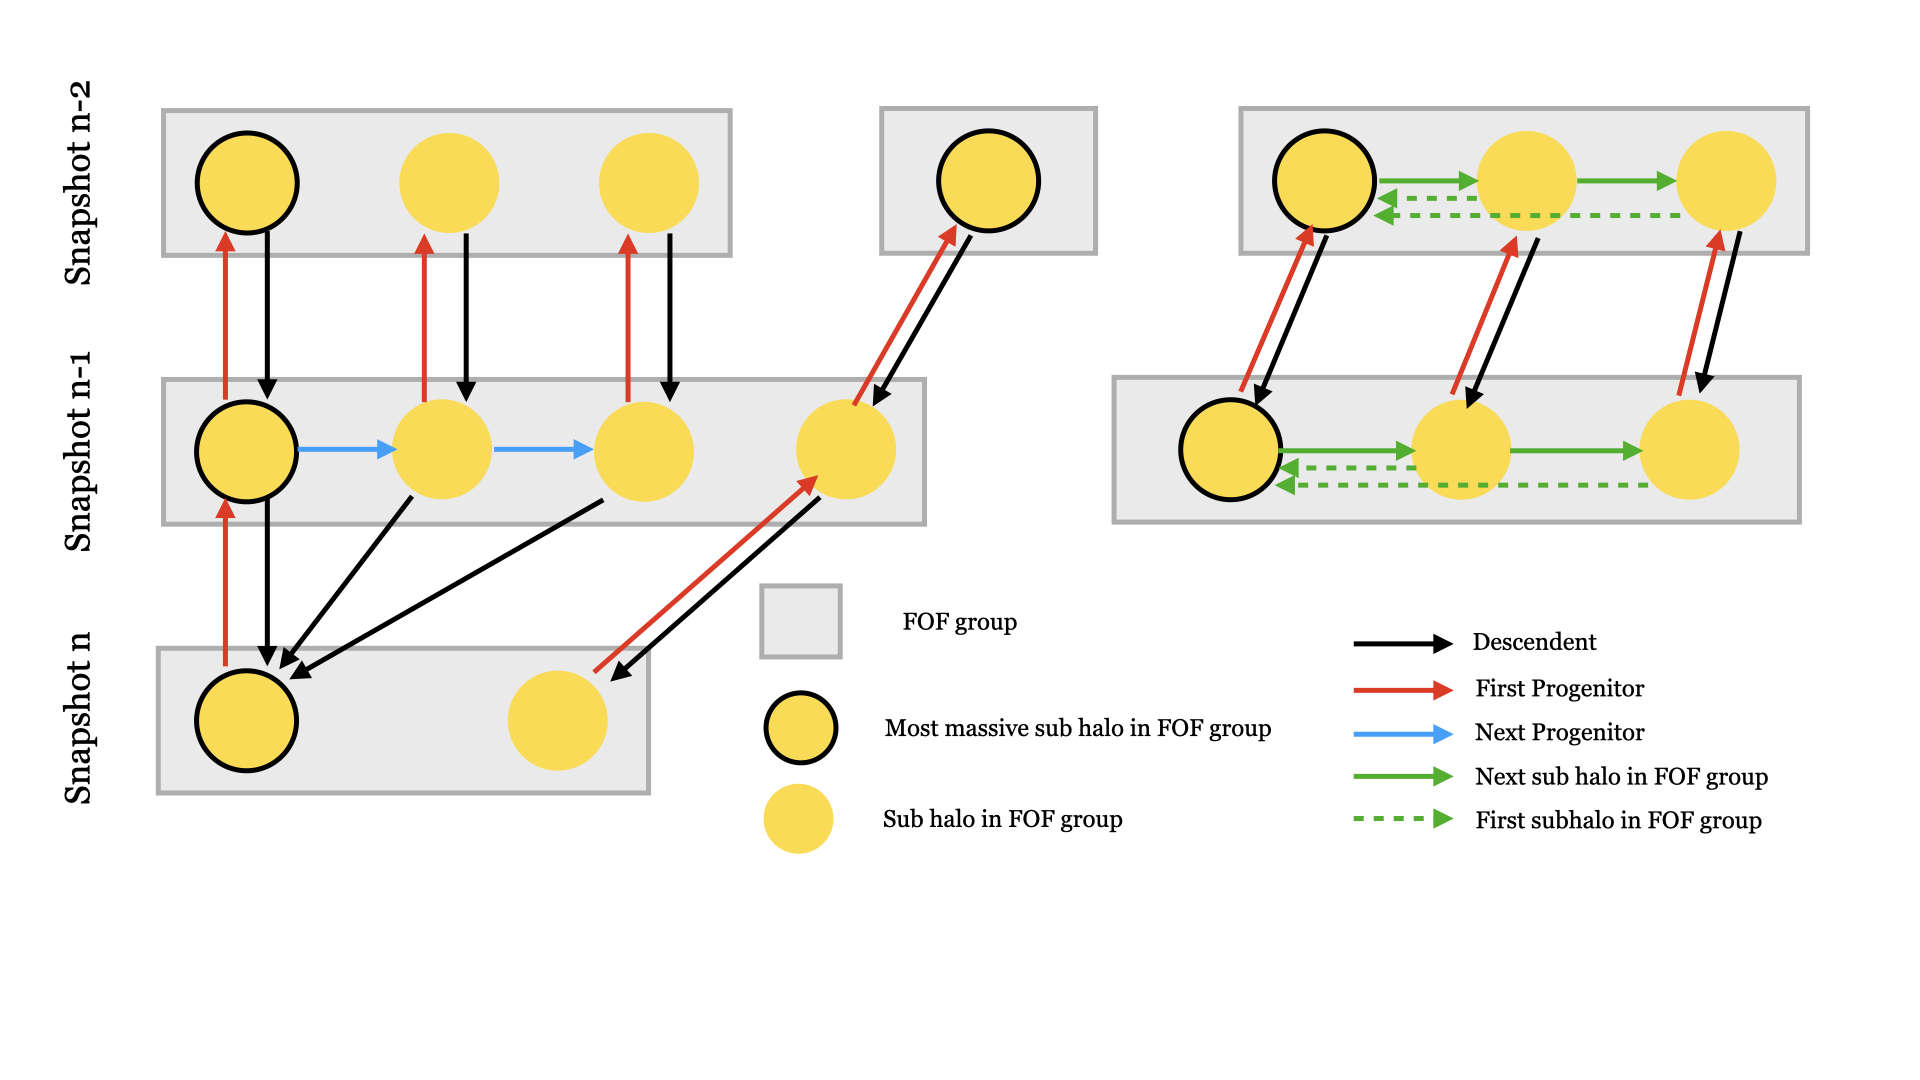

First, we need to load the object for the tree data:

In [ ]:
treeobj = ap.mergertree.load_mergertree(0, 0, snap_num, directory=tree_directory)

We can now use the tree methods (below) to give use the entire history of various data fields for a given object. We only need 3 numbers to specify a unique object in the tree:

i) the snapshot number

ii) the FOF number of the object

iii) the subhalo number of the object

In [ ]:
"""
def GetObjectHistoryFromSubhaloID()
      Parameters:
          subhaloid:    int
                        id of the object from the subfind/group catalogue
          snapshot:     int
                        number of the snapshot at which the subhaloid and groupid are defined
          groupid:      int
                        FoF group number of the object from the subfind/group catalogue
          fields:       list
                        desired data fields of the given object from the tree
          mainprogonly: boolean
                        if True, return only the first progenitors of this object. If False, return the first and next progenitors of object. Default is True.
      Returns
          Dictionary of data fields for the progenitors of the specified object given for each preceding snapshot
"""

Let's do this for mass and redshift of the main object at the final snapshot (i.e. groupid=0; subhaloid=0; snapshot=snap_num=127):

In [ ]:
result = treeobj.GetObjectHistoryFromSubhaloID(0, snap_num, 0, ['SubhaloMassType', 'Redshift', 'SubhaloPos'])
print('result=',result)

Here we can see how the result is structured - as a dictionary with the attributes we requested. Some of the tree data attributes, such as coordinates (e.g. 'SubhaloPos') and masses (e.g. 'SubhaloMassType') are automatically converted from comoving to physical on loading the data with the load_mergertree() class (see the details of the transform_to_physical_units() method in mergertree.py to see which attrbiutes are converted; additional attributes will need to be manually converted by the User). For the 'SubhaloMassType' that we use here, the physical units are in 1e10 Solar masses, so we will multiply by this factor to get Solar masses.

In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
ax1.plot(result['Redshift'], result['SubhaloMassType'][:,:,1]*1e10)
ax1.set_xlabel('$\\rm redshift $')
ax1.set_ylabel('$\\rm{DM \, mass \, [M_{\odot}]}$')
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlim(0.01,4.)
ax1.set_ylim(1e10, 2e12)
fig.show()

Let's plot the dark matter mass evolution of the most massive satellite at redshift zero in the FOF with groupid=0. This has the subhaloid=1. We will request only the main progenitor branch of this halo which returns the 'FirstProgenitor' indices of this object (i.e. the main progenitor of the object at each prior snapshot) and not all the 'NextProgenitor' objects:

In [ ]:
result_main = treeobj.GetObjectHistoryFromSubhaloID(1, snap_num, 0, ['SubhaloMassType', 'Redshift'], mainprogonly=True)
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
ax1.plot(result_main['Redshift'], result_main['SubhaloMassType'][:,:,1]*1e10)
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlim(0.01,10.)
ax1.set_ylim(1e8, 5e11)
fig.show()

Now, let's find when all the satellites (defined at z=0) reached their maximum mass and the fraction of dark matter mass that has been lost at z=0

In [ ]:
attrstoload = ['SubhaloMass', 'SubhaloPos', 'SubhaloVel', 'SubhaloMassType', 'Group_R_Crit200']
#main_pos = treeobj.data['SubhaloPos'][indices]
main_pos = result['SubhaloPos']
distance = np.sqrt( np.sum( (subobj.data['SubhaloPos']-main_pos[0,:])**2, axis=1) )
print('distances=',distance)
ii, = np.where( (distance <= r200) & (distance > 0) )
print('ii',ii)

In [ ]:
nsubhalos = len(ii)
fraction_lost = np.zeros(nsubhalos)
for i, isub in enumerate(range(nsubhalos)):
    result = treeobj.GetObjectHistoryFromSubhaloID(isub, snap_num, 0, ['SubhaloMassType', 'SubhaloPos', 'Redshift'], mainprogonly=True)
    dmmass = result['SubhaloMassType'][:,:,1].squeeze()
    maxdmmass = np.nanmax(dmmass)
    fraction_lost[i] = 1 - (dmmass[0] / maxdmmass)

print('distance, fraction_lost=',distance,fraction_lost)

plt.scatter(distance[ii], fraction_lost)
plt.show()

# **Supplementary information for accreted stars - combining snapshots, group catalogues, and merger trees**

By combining the information from the snapshots, group/subhalo catalogues and the merger trees, we can calculate additional information about the star particles found inside R200 at z=0. This information is designed to be particularly useful for understanding the origin and accretion history of star particles that were born elsewhere and later accreted into the main halo, and that exist in the final snapshot as either disrupted debris or part of a satellite galaxy.

The data fields are:

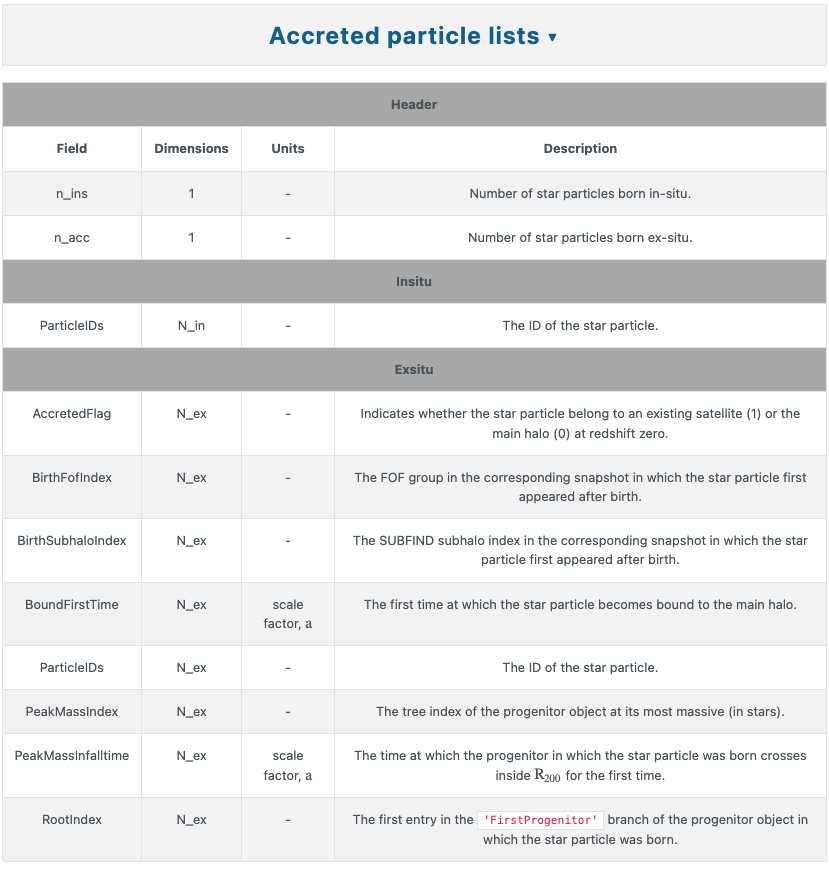

These data are structured in a series of files, one for each snapshot of the simulation that contains only the star particles born in that snapshot. Thus, all files should be loaded to get a complete list of all the star particles found within the R200 of the halo at redshift zero.

In [ ]:
mdata = ap.util.read_starparticle_mergertree_data_hdf5(snap_num, list_directory, halo)
print(mdata)

Using the 'PeakMassIndex' attribute of each star particle, we can determine the list of progenitor galaxies that make up the accreted component of the Milky Way at z=0. The 'PeakMassIndex' is the tree index of the object when it reached its peak stellar mass, so star particles with the same 'PeakMassIndex' were born in the same object. 

In the following, we produce a list of the (fully disrupted; 'AccretedFlag'=0) progenitors in order of descending peak stellar mass:

In [ ]:
first_prog = np.array(sorted(set(list(mdata['Exsitu']['PeakMassIndex']))))
print('first_prog=',first_prog,len(first_prog))
"""Count the number of star particles that are now bound to the main halo from each progenitor system, and sort in descending order of mass"""
nstars_in_subhalo = np.zeros(len(first_prog))
for i, pid in enumerate(first_prog):
    nstars_in_subhalo[i] = np.sum( (mdata['Exsitu']['PeakMassIndex']==pid) & (mdata['Exsitu']['AccretedFlag']==0))

print('finished finding stars for each progenitor.')
nsort = np.argsort(nstars_in_subhalo)[::-1]
nstars_in_subhalo = nstars_in_subhalo[nsort].astype('int')
first_prog = first_prog[nsort]
print('first_prog=',first_prog,len(first_prog))
print('nstars_in_subhalo=',nstars_in_subhalo)


We can then use this information to get the ParticleIDs of stars that belonged to a particular progenitor, find them in the snapshot, and plot any properties we want. 

For example, to select those from the 3rd most massive progenitor, we get the indices for which 'PeakMassIndex'=2382 and retrieve the corresponding array of 21022 'ParticleIDs'.Combining this with other information in the accreted particle list data, such as the 'BoundFirstTime', we may make plots of the redshift 0 XYZ distribution of these star particles coloured according to the time at which they first became unbound from their progenitor and therefore became bound to the main halo.
### Plot the spatial distribution (XYZ projections) of accreted stars that belonged to the 3rd most massive progenitor, and colour the points according to the time that each particle became first bound to the MW

In [ ]:
"""Select 3rd most massive progenitor that merged with the MW"""
index = 2
index_firstprog, = np.where( ( mdata['Exsitu']['PeakMassIndex'] == first_prog[index] ) & (mdata['Exsitu']['AccretedFlag'] == 0) )
id_index_prog, = np.where( np.isin( snapobj.data['ParticleIDs'], mdata['Exsitu']['ParticleIDs'][index_firstprog] ) )
prog_star_positions = snapobj.data['Coordinates'][id_index_prog]

snapfb_thisprog = mdata['Exsitu']['BoundFirstTime'][index_firstprog]
c_index, = np.where( np.isin(mdata['Exsitu']['ParticleIDs'][index_firstprog], snapobj.data['ParticleIDs']) )
isort2 = np.argsort(mdata['Exsitu']['ParticleIDs'][ index_firstprog ][c_index])
pcolors = ( snapfb_thisprog[c_index[isort2]] - snapfb_thisprog.min() ) / ( snapfb_thisprog.max() - snapfb_thisprog.min() )

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].scatter( prog_star_positions[:,1]*1e3, prog_star_positions[:,2]*1e3, c=pcolors, s=5., marker='.', linewidth=0, cmap=plt.get_cmap('viridis'), alpha=0.2 )
ax[1].scatter( prog_star_positions[:,1]*1e3, prog_star_positions[:,0]*1e3, c=pcolors, s=5., marker='.', linewidth=0, cmap=plt.get_cmap('viridis'), alpha=0.2 )
ax[2].scatter( prog_star_positions[:,2]*1e3, prog_star_positions[:,0]*1e3, c=pcolors, s=5., marker='.', linewidth=0, cmap=plt.get_cmap('viridis'), alpha=0.2 )
fig.show()

Here, we see that this particular satellite has accreted over several pericentric passages, leaving shells of different extents that each comprise stars with different accretion times as defined as when they become bound to the main halo.

### Plot accreted star particles AND those still bound in satellite galaxies in the R-VR plane.

In [ ]:
index_accreted, = np.where((mdata['Exsitu']['AccretedFlag']==0))
id_index, = np.where( np.isin( snapobj.data['ParticleIDs'], mdata['Exsitu']['ParticleIDs'][index_accreted] ) )
prog_star_positions = snapobj.data['Coordinates'][id_index]
prog_star_velocities = snapobj.data['Velocities'][id_index]
radii = np.sqrt( np.sum(prog_star_positions**2, axis=1) )
radial_velocities = np.sum(prog_star_positions * prog_star_velocities, axis=1) / radii

fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
ax.scatter( radii, radial_velocities, c='r', s=5, marker='.', linewidth=0, alpha=0.2 )

index_insat, = np.where((mdata['Exsitu']['AccretedFlag']==1))
id_index, = np.where( np.isin( snapobj.data['ParticleIDs'], mdata['Exsitu']['ParticleIDs'][index_insat] ) )
prog_star_positions = snapobj.data['Coordinates'][id_index]
prog_star_velocities = snapobj.data['Velocities'][id_index]
radii = np.sqrt( np.sum(prog_star_positions**2, axis=1) )
radial_velocities = np.sum(prog_star_positions * prog_star_velocities, axis=1) / radii
ax.scatter( radii, radial_velocities, c='b', s=5, marker='.', linewidth=0, alpha=0.2 )
fig.show()

Finally, we will plot the star particles in angular momentum - energy space (E-Lz).

Note that the total energy, given by

\begin{equation}
E = U + KE
\end{equation}

can actually be positive when using the raw snapshot data. This is a consequence of the global potential in a periodic box, which is the potential of the density relative to the average in the box: underdense parts of the Universe will have positive values. So we must think about what the values of E mean when normalising E.

### Calculate the orbital energy of star particles and plot the E-Lz plot for all particles and the 3rd most massive progenitor

In [ ]:
potential = snapobj.data['Potential']
print(potential.min(),potential.max())

kinetic_energy = np.sum(snapobj.data['Velocities']**2, axis=1)
print(kinetic_energy)

orbital_energy = potential + 0.5 * kinetic_energy
orbital_energy /= 1e5
print(orbital_energy.min(),orbital_energy.max())
orbital_energy -= orbital_energy.max()
print(orbital_energy.min(),orbital_energy.max())
Lz = np.cross( snapobj.data['Coordinates'], (snapobj.data['Velocities'] ) )[:,0]
Lz *= np.sign(np.nanmedian(Lz))

from matplotlib.colors import LogNorm
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5), tight_layout=True)
index, = np.where((ap.util.r(snapobj) < 0.1) & (ap.util.r(snapobj) > 0.0))
ax.hist2d( Lz[index], orbital_energy[index], bins=(100, 100), range=([-5, 5], [-2.2, 0.]), rasterized=True, cmap='Greys', norm=LogNorm() )
ax.scatter( Lz[id_index_prog], orbital_energy[id_index_prog], c='b', s=5, marker='.', linewidth=0, alpha=0.2 )
fig.show()

### Calculate the infall time of a progenitor
Given the progenitor IDs (defined by the 'first_prog' variable above) that contribute to the accreted stellar component of the MW at redshift 0, let's get the infall time of one of the progenitors (defined as the time at which the object crosses inside the R200 of the MW for the first time):

In [ ]:
"""This returns the tree index for the object 2382 at the time of its infall, as well as the tree index for the main MW progenitor at the same time"""
infall_index, infall_index_main, distance = treeobj.GetProgenitorInfallIndex(2382)

infall_time = ap.util.GetLookbackTimeFromScaleFactor_Flat(1./(1.+treeobj.data['Redshift'][infall_index]), snapobj.hubbleparam, snapobj.omega0, snapobj.omegalambda)

print('infall_time=',infall_time)


then use these indices to calculate the total mass ratio and stellar mass ratio of the object at the time of infall:

In [ ]:
TotalmassRatioAtInfall = treeobj.data['SubhaloMassType'][infall_index].sum() / treeobj.data['SubhaloMassType'][infall_index_main].sum()
print('TotalmassRatioAtInfall=',TotalmassRatioAtInfall)

StellarmassRatioAtInfall = treeobj.data['SubhaloMassType'][infall_index,4] / treeobj.data['SubhaloMassType'][infall_index_main,4]
print('StellarmassRatioAtInfall=',StellarmassRatioAtInfall)